# Fuel Shock Stress Test: analysis notebook

**Question:** what share of trucking companies survive an oil price shock, who is most vulnerable, and who recovers fastest?

Sections:
1. Oil price history and realized volatility (public data)
2. Crude-to-pump pass-through: the tax wedge finding
3. Company screen (CapitalIQ export, local only, not yet provided, section is a stub)
4. Ornstein-Uhlenbeck calibration and Monte Carlo
5. Vulnerability ranking (headline result)
6. Next steps

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from monte_carlo import calibrate_ou, simulate_ou_paths, margin_path, COUNTRIES, HORIZON_MONTHS, N_PATHS, SEED

brent = pd.read_csv('../data/public/brent_usd_bbl_daily.csv', parse_dates=['date']).set_index('date')['value']
wti = pd.read_csv('../data/public/wti_usd_bbl_daily.csv', parse_dates=['date']).set_index('date')['value']
diesel = pd.read_csv('../data/public/us_diesel_usd_gal_weekly.csv', parse_dates=['date']).set_index('date')['value']
print('Brent rows:', len(brent), 'to', brent.index.max().date())
print('US diesel rows:', len(diesel), 'to', diesel.index.max().date())

Brent rows: 9922 to 2026-06-29
US diesel rows: 1685 to 2026-06-29


## 1. Price history and realized volatility

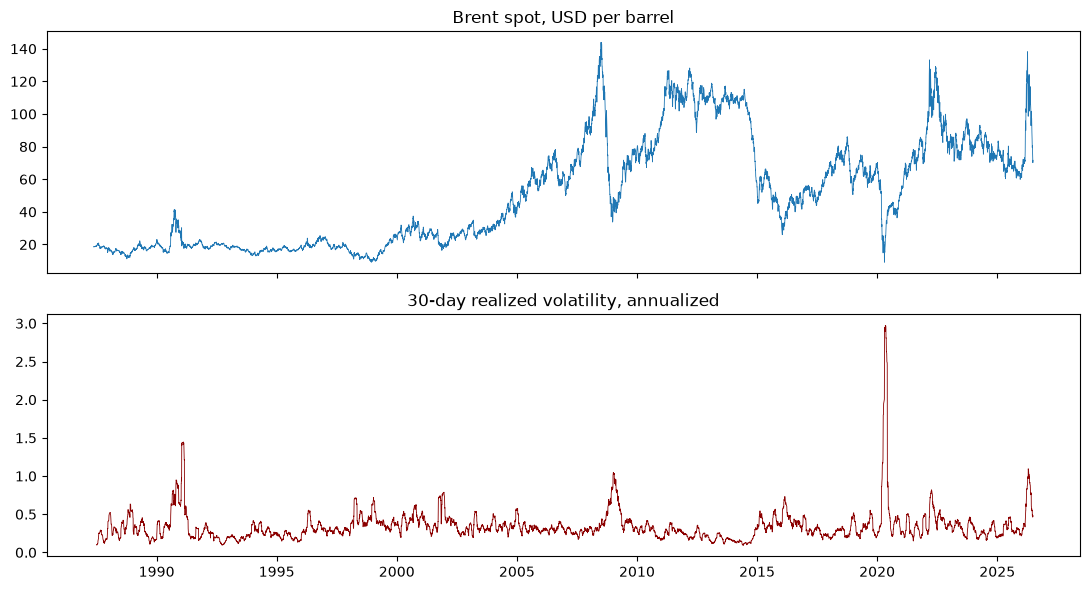

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(brent.index, brent.values, lw=0.6)
axes[0].set_title('Brent spot, USD per barrel')
ret = np.log(brent).diff()
vol30 = ret.rolling(30).std() * np.sqrt(252)
axes[1].plot(brent.index, vol30, lw=0.6, color='darkred')
axes[1].set_title('30-day realized volatility, annualized')
plt.tight_layout()
plt.show()

## 2. Crude-to-pump pass-through: the tax wedge

13-week percent changes in Brent regressed against 13-week percent changes in US retail diesel. Finding: beta is approximately 0.36 (R-squared 0.51), not the naive 1:1 many people assume. Retail diesel absorbs crude moves slowly and only partially: taxes, refining margin and distribution costs don't move with crude. This is the empirical anchor for the US Crude-to-pump beta in the Excel model. The other four countries still use v0 estimates of their tax wedge (India, Germany and Brazil tax fuel heavily and so should show an even lower beta than the US in local-currency terms; China's administered pricing behaves differently again), calibrating those four with Eurostat, PPAC, NDRC, ANP, or Bloomberg is the next data task.

US crude-to-pump beta (13wk moves, 1994-06-20 to 2026-06-29 ):
beta=0.390  R2=0.511  n=1672


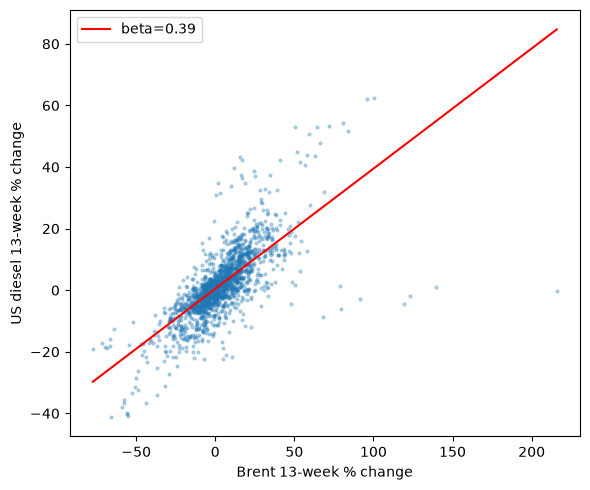

In [3]:
bw = brent.resample('W-MON').mean()
merged = pd.concat([bw.rename('brent'), diesel.rename('diesel')], axis=1).dropna()
chg = merged.pct_change(13).dropna()
beta, alpha = np.polyfit(chg['brent'], chg['diesel'], 1)
r2 = np.corrcoef(chg['brent'], chg['diesel'])[0, 1] ** 2
print('US crude-to-pump beta (13wk moves,', chg.index.min().date(), 'to', chg.index.max().date(), '):')
print(f'beta={beta:.3f}  R2={r2:.3f}  n={len(chg)}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(chg['brent'] * 100, chg['diesel'] * 100, s=4, alpha=0.3)
xs = np.linspace(chg['brent'].min(), chg['brent'].max(), 50)
ax.plot(xs * 100, (alpha + beta * xs) * 100, color='red', lw=1.5, label=f'beta={beta:.2f}')
ax.set_xlabel('Brent 13-week % change')
ax.set_ylabel('US diesel 13-week % change')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Company screen (CapitalIQ export)

Not yet provided. Drop the CIQ export at ../data/licensed/ciq_screen.xlsx (gitignored) with: name, ticker, country, market cap, revenue, EBITDA margin, EBIT margin (FY2015 to FY2025), cash and short-term investments, total debt, interest expense, employees, for GICS Ground Transportation/Trucking and Air Freight and Logistics companies headquartered in the five focus countries. Once it lands, this section applies the shock and Monte Carlo engine to the actual distribution of company margins and cash buffers instead of one representative operator per country, which is the upgrade that turns 'vulnerability by country' into 'which named companies breach, and at what fleet or revenue scale.'

In [4]:
import os
ciq_path = '../data/licensed/ciq_screen.xlsx'
if os.path.exists(ciq_path):
    ciq = pd.read_excel(ciq_path)
    print(ciq.shape)
    ciq.head()
else:
    print('ciq_screen.xlsx not found yet, section 3 is a stub until it is provided')

ciq_screen.xlsx not found yet, section 3 is a stub until it is provided


## 4. Ornstein-Uhlenbeck calibration and Monte Carlo

Oil mean-reverts (a shock decays back toward a long-run level), so a plain geometric Brownian motion would overstate how far prices drift over a 12-month horizon. Calibrated here as an AR(1) on log Brent since 2010, mapped to continuous-time OU parameters.

half-life (years): 0.87
long-run mean ($/bbl): 73.2
current price2026-06-29: $71.6


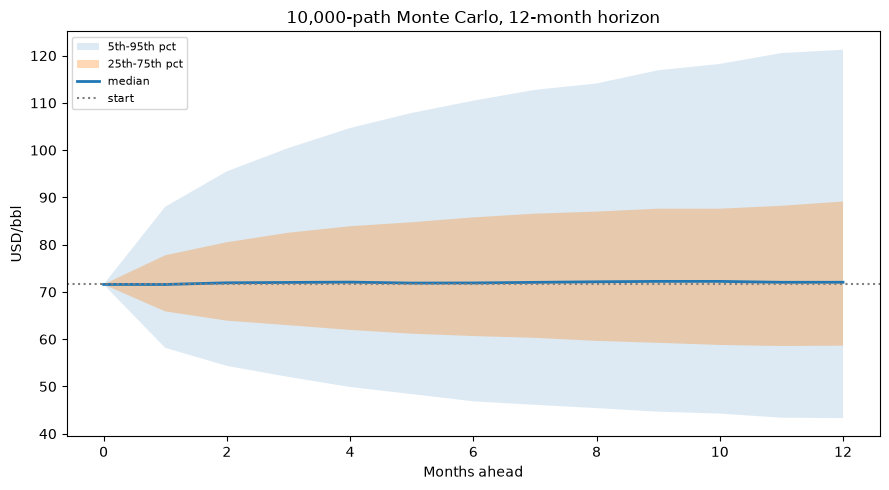

In [5]:
params = calibrate_ou(brent, start='2010-01-01')
print('half-life (years):', round(np.log(2) / params['theta'], 2))
print('long-run mean ($/bbl):', round(params['mu_level'], 1))
print('current price', params['last_date'], ': $', round(params['last_price'], 1), sep='')

paths = simulate_ou_paths(params, HORIZON_MONTHS, N_PATHS, SEED)
months = np.arange(HORIZON_MONTHS + 1)
pct = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(months, pct[0], pct[4], alpha=0.15, label='5th-95th pct')
ax.fill_between(months, pct[1], pct[3], alpha=0.3, label='25th-75th pct')
ax.plot(months, pct[2], lw=2, label='median')
ax.axhline(params['last_price'], ls=':', color='gray', label='start')
ax.set_xlabel('Months ahead')
ax.set_ylabel('USD/bbl')
ax.set_title(f'{N_PATHS:,}-path Monte Carlo, {HORIZON_MONTHS}-month horizon')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Vulnerability ranking (headline result)

Each simulated price path is run through the same margin logic as the Excel ShockEngine sheet (fuel share of revenue times pass-through-adjusted price move), using v0 baseline economics per country (see excel/Inputs). Result: Brazil has a 42 percent chance of breaching zero EBIT margin at some point in the next 12 months; the US has effectively none. The ranking (Brazil, China, India, Germany, US, from most to least vulnerable) follows directly from each country's fuel share of revenue and its baseline margin cushion, not from the size of the oil shock itself, which is identical across countries in this simulation. That is the core finding of this project: exposure is structural, not just about how bad the shock is.

In [6]:
rows = []
for name, c in COUNTRIES.items():
    m = margin_path(paths, params['last_price'], c)
    rows.append({
        'country': name,
        'baseline_margin': c['margin0'],
        'fuel_share_of_revenue': c['fuel_share_rev'],
        'p_breach_ever_12mo': (m < 0).any(axis=1).mean(),
        'median_min_margin': np.median(m.min(axis=1)),
    })
result = pd.DataFrame(rows).sort_values('p_breach_ever_12mo', ascending=False)
result

,country,baseline_margin,fuel_share_of_revenue,p_breach_ever_12mo,median_min_margin
4,Brazil,0.060,0.463,0.4229,0.009717
2,China,0.070,0.389,0.2320,0.031003
1,India,0.086,0.466,0.1437,0.047070
3,Germany,0.076,0.324,0.0450,0.051639
0,US,0.090,0.242,0.0005,0.075444


## 6. Next steps

- Calibrate crude-to-pump beta for India, China, Germany, Brazil (Eurostat oil bulletin, PPAC, NDRC, ANP, or Bloomberg country diesel series).
- Ingest the CapitalIQ screen (section 3) and re-run the vulnerability ranking against actual company margins and cash buffers, not one representative operator.
- 2022 oil-spike backtest: which real companies recovered fastest, and what did they have in common (scale, contract mix, hedging)?
- Bounded food-price section: transport share of food retail price times shock scenario.